# Medical Image Classification: Detecting Pneumonia on Chest X-rays

This demo trains a neural network to recognize pneumonia on children's chest X-rays, then evaluates it the way a medical tool must be evaluated. It runs end to end without writing any code: run the cells in order (menu `Runtime > Run all`). It takes a few minutes on Colab's GPU.

What we'll do:

1. look at the images and count the classes: there are many more pneumonia cases than normal X-rays;
2. adapt a network already trained on millions of photos (transfer learning);
3. evaluate it: beyond accuracy, how many pneumonia cases does it miss, how many false alarms does it raise?
4. choose the decision threshold;
5. say what such a model is not.

**Data.** [PneumoniaMNIST](https://medmnist.github.io/), from the MedMNIST v3 collection, at 128 × 128 pixels, under the [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/) license:

- Jiancheng Yang, Rui Shi, Donglai Wei, Zequan Liu, Lin Zhao, Bilian Ke, Hanspeter Pfister, Bingbing Ni. "[MedMNIST v2 - A large-scale lightweight benchmark for 2D and 3D biomedical image classification](https://doi.org/10.1038/s41597-022-01721-8)". *Scientific Data*, 2023.
- Source of the X-rays: Daniel S. Kermany *et al.* "[Identifying Medical Diagnoses and Treatable Diseases by Image-Based Deep Learning](https://doi.org/10.1016/j.cell.2018.02.010)". *Cell*, 2018.

## Checking GPU Usage

Go to the `Runtime > Change runtime type` menu and check that the hardware accelerator is set to "GPU". Without a GPU, the demo works too, but takes about ten minutes.

In [1]:
!nvidia-smi

Wed Oct  7 17:46:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:04:00.0 Off |                    0 |
| N/A   50C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Importing the Required Libraries

In [2]:
import matplotlib.pyplot as plt
import numpy
import pandas
import seaborn
import sklearn.metrics
import tensorflow as tf
import keras

# So that two runs give roughly the same results
keras.utils.set_random_seed(42)

## The Data

The dataset is a single file (75 MB), already split into three parts:

- **training**: the images the model learns from;
- **validation**: images set aside to monitor training and make our choices;
- **test**: images the model never sees before the final evaluation.

In [3]:
!wget -q -O pneumoniamnist_128.npz "https://zenodo.org/records/10519652/files/pneumoniamnist_128.npz?download=1"
!ls -lh pneumoniamnist_128.npz

-rw-r--r-- 1 root root 73M Oct  7 17:47 pneumoniamnist_128.npz


In [4]:
data = numpy.load("pneumoniamnist_128.npz")

# Grayscale images of 128x128 pixels (values from 0 to 255).
# Labels: 0 for a normal X-ray, 1 for pneumonia.
train_images, train_labels = data["train_images"], data["train_labels"].ravel()
val_images, val_labels = data["val_images"], data["val_labels"].ravel()
test_images, test_labels = data["test_images"], data["test_labels"].ravel()

LABEL_NAMES = ["normal", "pneumonia"]

for split, labels in [("Training", train_labels),
                      ("Validation", val_labels),
                      ("Test", test_labels)]:
  share = round(100 * labels.mean(), 1)
  print(f"{split}: {len(labels)} images, {share}% of them pneumonia")

Training: 4708 images, 74.2% of them pneumonia
Validation: 524 images, 74.2% of them pneumonia
Test: 624 images, 62.5% of them pneumonia


## Looking at the Images

On an X-ray, air shows up black and dense tissue white. Healthy lungs are dark and clear; pneumonia fills part of the lungs with fluid, which forms white, blurry areas ("opacities"). The difference is far from obvious to an untrained eye.

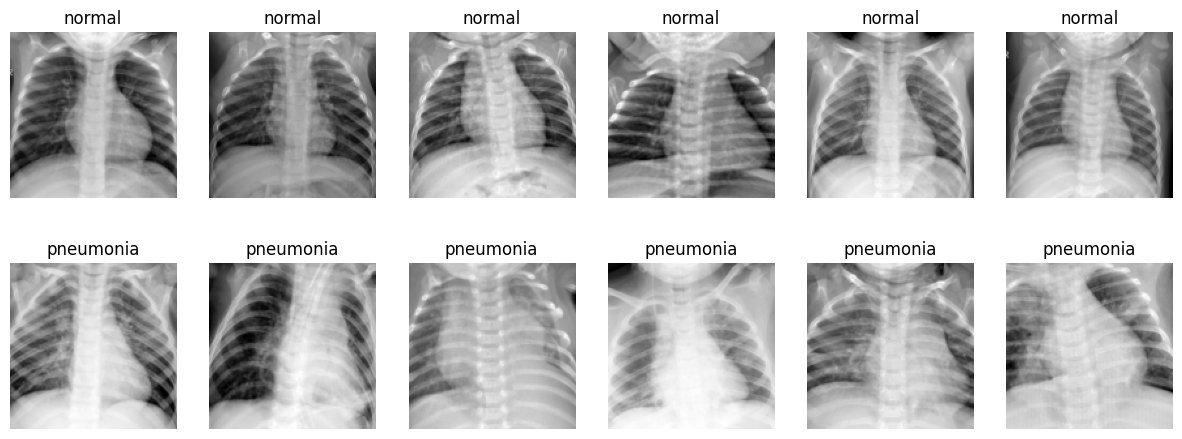

In [5]:
# 6 X-rays of each class, drawn at random from the training set
_, axes = plt.subplots(2, 6, figsize=(15, 5.5))
for label, row in enumerate(axes):
  indexes = numpy.random.choice(numpy.flatnonzero(train_labels == label),
                                size=6,
                                replace=False)
  for ax, index in zip(row, indexes):
    ax.imshow(train_images[index], cmap="gray")
    ax.set_title(LABEL_NAMES[label])
    ax.axis("off")
plt.show()

## The Accuracy Trap

The classes are imbalanced: three training X-rays out of four show pneumonia. Let's see how a "model" that doesn't even look at the image and always answers "pneumonia" does. Two measures:

- **accuracy**: the share of correct answers;
- **recall**: the share of pneumonia cases the model finds.

In [6]:
# A "model" that always answers "pneumonia" (1), without looking at the image
always_pneumonia = numpy.ones_like(test_labels)
accuracy = sklearn.metrics.accuracy_score(test_labels, always_pneumonia)
recall = sklearn.metrics.recall_score(test_labels, always_pneumonia)
print(f"Test accuracy: {accuracy:.1%}")
print(f"Test recall: {recall:.1%}")

Test accuracy: 62.5%
Test recall: 100.0%


Without learning anything, this "model" has 62.5% accuracy on the test set (and 74% on the training set), and a perfect recall: it misses no pneumonia... because it declares everyone sick. Accuracy alone means nothing: it must be compared with this baseline, and we must look at **which** errors the model makes.

## The Model: a Pretrained Network

Training a neural network from scratch would take far more than our 4,708 images. So we start from **EfficientNetV2B0**, a network already trained on ImageNet (1.2 million everyday photos, not a single X-ray). Its layers have learned to spot edges, textures and shapes, which helps with X-rays too: this is **transfer learning**.

We replace its last layer with a single neuron, which gives the probability of pneumonia, between 0 and 1. Training takes two steps:

1. the pretrained network stays frozen, only the new layer learns;
2. we "unfreeze" its last layers to refine them (*fine-tuning*) on the X-rays.

The network expects color images: we copy the gray channel into the three red, green and blue channels.

In [7]:
IMAGE_SIZE = 128
BATCH_SIZE = 32


def make_dataset(images: numpy.ndarray,
                 labels: numpy.ndarray,
                 shuffle: bool = False) -> tf.data.Dataset:
  dataset = tf.data.Dataset.from_tensor_slices((images[..., None], labels))
  if shuffle:
    dataset = dataset.shuffle(len(images), seed=42)
  # The gray channel copied into 3 channels (red, green, blue)
  return (dataset.batch(BATCH_SIZE)
          .map(lambda x, y: (tf.image.grayscale_to_rgb(tf.cast(x, tf.float32)), y))
          .prefetch(tf.data.AUTOTUNE))


train_dataset = make_dataset(train_images, train_labels, shuffle=True)
val_dataset = make_dataset(val_images, val_labels)
test_dataset = make_dataset(test_images, test_labels)

In [8]:
# The network pretrained on ImageNet, without its last layer (include_top=False).
# It normalizes the pixels itself: it takes values from 0 to 255.
base_model = keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    pooling="avg")
base_model.trainable = False

inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
# training=False: its normalization layers keep the statistics learned on
# ImageNet, including when we fine-tune it
features = base_model(inputs, training=False)
features = keras.layers.Dropout(0.2)(features)
# A single output neuron: the probability of pneumonia, between 0 and 1
outputs = keras.layers.Dense(1, activation="sigmoid")(features)
model = keras.Model(inputs, outputs, name="pneumonia_classifier")

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "pneumonia_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 1280)           │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,920,593 (22.59 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

The summary shows about 5.9 million parameters, of which only 1,281 are trainable: those of the new neuron. Everything else comes from ImageNet.

## Training

### Step 1: Only the New Layer Learns

An *epoch* is one pass over all the training images. After each one, Keras shows the accuracy and the loss (the error that training brings down) on the training set, then on the validation set (`val_accuracy`, `val_loss`).

In [9]:
history_head = model.fit(train_dataset, validation_data=val_dataset, epochs=3)

Epoch 1/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 67s 249ms/step - accuracy: 0.8685 - loss: 0.3092 - val_accuracy: 0.9332 - val_loss: 0.1954
Epoch 2/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.9244 - loss: 0.1918 - val_accuracy: 0.9485 - val_loss: 0.1602
Epoch 3/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9356 - loss: 0.1649 - val_accuracy: 0.9466 - val_loss: 0.1502


### Step 2: Fine-tuning the Network's Last Layers

In [10]:
def plot_history(histories: list) -> None:
  # The curves of both training steps, end to end
  metrics = {key: sum((history.history[key] for history in histories), [])
             for key in ("accuracy", "val_accuracy", "loss", "val_loss")}
  epochs = range(1, len(metrics["loss"]) + 1)
  _, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
  ax1.plot(epochs, metrics["accuracy"], label="Training")
  ax1.plot(epochs, metrics["val_accuracy"], label="Validation")
  ax1.set_title("Accuracy")
  ax1.set_xlabel("Epoch")
  ax1.legend()
  ax2.plot(epochs, metrics["loss"], label="Training")
  ax2.plot(epochs, metrics["val_loss"], label="Validation")
  ax2.set_title("Loss")
  ax2.set_xlabel("Epoch")
  ax2.legend()
  plt.show()

Epoch 1/4
148/148 ━━━━━━━━━━━━━━━━━━━━ 56s 188ms/step - accuracy: 0.9465 - loss: 0.1307 - val_accuracy: 0.9695 - val_loss: 0.0889
Epoch 2/4
148/148 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.9628 - loss: 0.0953 - val_accuracy: 0.9618 - val_loss: 0.0939
Epoch 3/4
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9677 - loss: 0.0774 - val_accuracy: 0.9752 - val_loss: 0.0744
Epoch 4/4
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9760 - loss: 0.0686 - val_accuracy: 0.9771 - val_loss: 0.0542


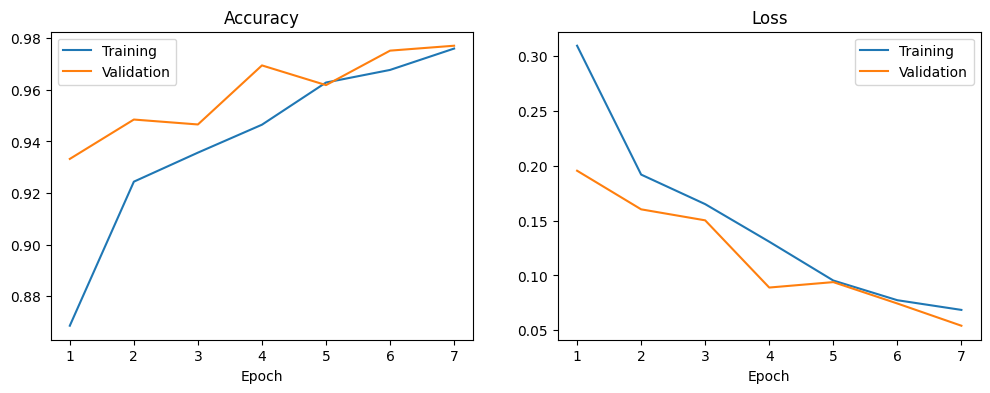

In [11]:
# We unfreeze the last 40 layers of the pretrained network, except its
# normalization layers (BatchNormalization), which are best kept frozen
base_model.trainable = True
for layer in base_model.layers[:-40]:
  layer.trainable = False
for layer in base_model.layers:
  if isinstance(layer, keras.layers.BatchNormalization):
    layer.trainable = False

# A learning rate 10 times smaller, to adjust without undoing everything.
# Recompiling the model takes the unfrozen layers into account.
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
              loss="binary_crossentropy",
              metrics=["accuracy"])

# Stop when the validation loss hasn't gone down for 2 epochs, and keep the
# weights of the best epoch
early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss",
                                               patience=2,
                                               restore_best_weights=True)
history_fine_tuning = model.fit(train_dataset,
                                validation_data=val_dataset,
                                epochs=4,
                                callbacks=[early_stopping])

plot_history([history_head, history_fine_tuning])

Validation accuracy goes from about 93% after the first epoch to about 97% after fine-tuning.

## Evaluation on the Test Set

For each X-ray, the model gives a probability of pneumonia. By default, we answer "pneumonia" when it exceeds 0.5: this is the **decision threshold**. Besides accuracy and recall, we measure:

- **precision**: among the X-rays the model declares "pneumonia", the share that really are, that is, how reliable an alert is.

The **confusion matrix** crosses the actual diagnosis (rows) with the model's prediction (columns). Bottom left, the **false negatives**: missed pneumonia cases. Top right, the **false positives**: false alarms on healthy children.

20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 678ms/step
Decision threshold: 0.50
Accuracy: 88.9%
Precision: 85.1%
Recall: 99.7%


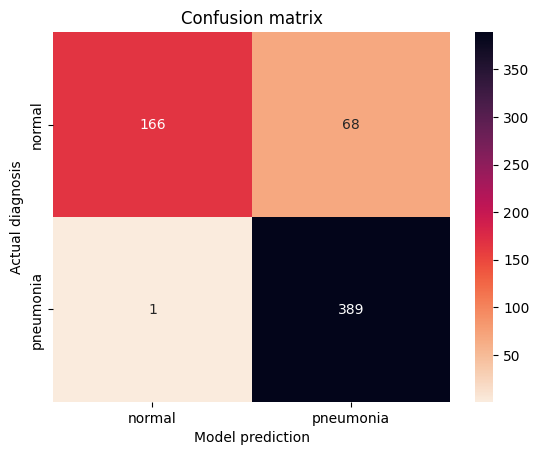

In [12]:
def evaluate(labels: numpy.ndarray,
             probabilities: numpy.ndarray,
             threshold: float = 0.5) -> None:
  predictions = (probabilities >= threshold).astype(int)
  print(f"Decision threshold: {threshold:.2f}")
  print(f"Accuracy: {sklearn.metrics.accuracy_score(labels, predictions):.1%}")
  print(f"Precision: {sklearn.metrics.precision_score(labels, predictions):.1%}")
  print(f"Recall: {sklearn.metrics.recall_score(labels, predictions):.1%}")
  confusion_matrix = sklearn.metrics.confusion_matrix(labels, predictions)
  seaborn.heatmap(confusion_matrix,
                  cmap="rocket_r",
                  xticklabels=LABEL_NAMES,
                  yticklabels=LABEL_NAMES,
                  annot=True,
                  fmt="d")
  plt.title("Confusion matrix")
  plt.xlabel("Model prediction")
  plt.ylabel("Actual diagnosis")
  plt.show()


test_probabilities = model.predict(test_dataset).ravel()
evaluate(test_labels, test_probabilities)

In our run (the figures vary a little from one run to the next): about 88% accuracy, against 62.5% for the "always pneumonia" baseline, and a recall above 99% (1 pneumonia case missed out of 390). But about 70 of the 234 healthy children are wrongly flagged: a precision of about 84%.

Two remarks:

- **Which error is worse?** In screening, a missed pneumonia (false negative) is worse than a false alarm, which a radiologist will check. So recall comes first. But too many false alarms waste time and cost the trust of medical staff.
- **Validation was optimistic**: about 97% accuracy on validation, about 88% on test. The test images come from another batch of patients, with another share of pneumonia (62.5% instead of 74%). Only truly new data tells what a model is worth.

## Choosing the Decision Threshold

The 0.5 threshold is a convention, not a medical choice. Lowering it finds more pneumonia cases (better recall) at the cost of more false alarms (worse precision); raising it does the opposite. The table below shows this trade-off on the test set.

In [13]:
# For several thresholds: how many missed pneumonia cases, how many false alarms?
rows = []
for threshold in [0.1, 0.3, 0.5, 0.7, 0.9, 0.95]:
  predictions = (test_probabilities >= threshold).astype(int)
  tn, fp, fn, tp = sklearn.metrics.confusion_matrix(test_labels, predictions).ravel()
  rows.append({"Threshold": threshold,
               "Accuracy": sklearn.metrics.accuracy_score(test_labels, predictions),
               "Precision": sklearn.metrics.precision_score(test_labels, predictions),
               "Recall": sklearn.metrics.recall_score(test_labels, predictions),
               "Missed pneumonia": fn,
               "False alarms": fp})
pandas.DataFrame(rows).round(3)

,Threshold,Accuracy,Precision,Recall,Missed pneumonia,False alarms
0,0.10,0.806,0.763,1.000,0,121
1,0.30,0.857,0.816,0.997,1,88
2,0.50,0.889,0.851,0.997,1,68
3,0.70,0.915,0.887,0.990,4,49
4,0.90,0.942,0.936,0.974,10,26
5,0.95,0.947,0.957,0.959,16,17


This table helps understand the trade-off, not choose: a threshold chosen by looking at the test set would make the test score too flattering (data leakage). The threshold is set on the **validation** set, from a goal set by doctors, not by data scientists. Here, the goal is a recall of at least 98%: at most 2 missed pneumonia cases out of 100. We take the highest threshold that reaches it on validation, then check on the test set.

(Another lever against imbalance is to give the rare class more weight during training, with the `class_weight` argument of `fit`.)

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 232ms/step


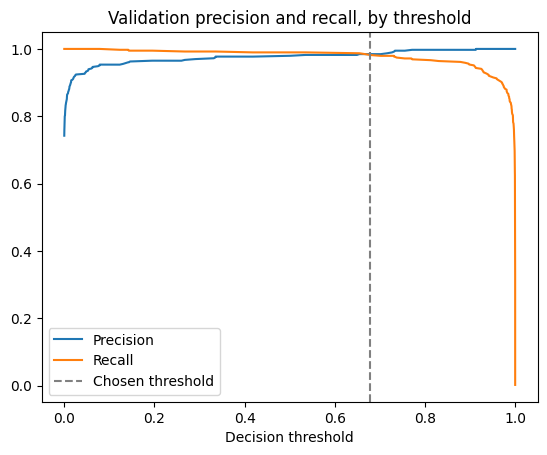

Decision threshold: 0.68
Accuracy: 90.9%
Precision: 87.9%
Recall: 99.0%


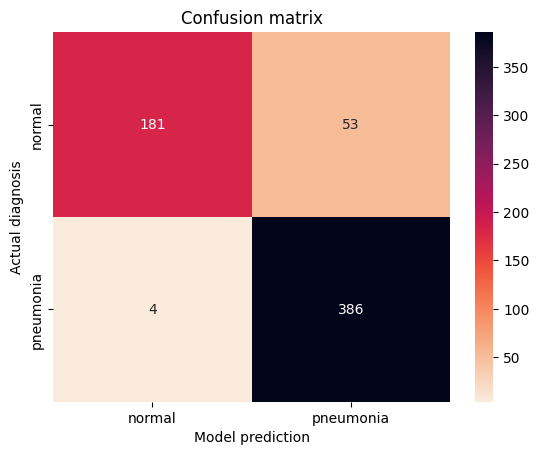

In [14]:
TARGET_RECALL = 0.98

val_probabilities = model.predict(val_dataset).ravel()
precisions, recalls, thresholds = sklearn.metrics.precision_recall_curve(
    val_labels, val_probabilities)
# precisions[i] and recalls[i] match the threshold thresholds[i] (both arrays
# have one more element, for an infinite threshold)
precisions, recalls = precisions[:-1], recalls[:-1]
chosen_threshold = thresholds[recalls >= TARGET_RECALL].max()

plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.axvline(chosen_threshold, color="gray", linestyle="--", label="Chosen threshold")
plt.title("Validation precision and recall, by threshold")
plt.xlabel("Decision threshold")
plt.legend()
plt.show()

evaluate(test_labels, test_probabilities, chosen_threshold)

In our run, the chosen threshold is about 0.74. On the test set, recall stays at 99% (4 pneumonia cases missed out of 390) and false alarms go from about 70 to about 50: 3 more missed pneumonia cases for about twenty fewer false alarms. This is the kind of trade-off doctors have to decide.

## Looking at the Errors

A few missed pneumonia cases and a few false alarms, with the probability of pneumonia the model gives them.

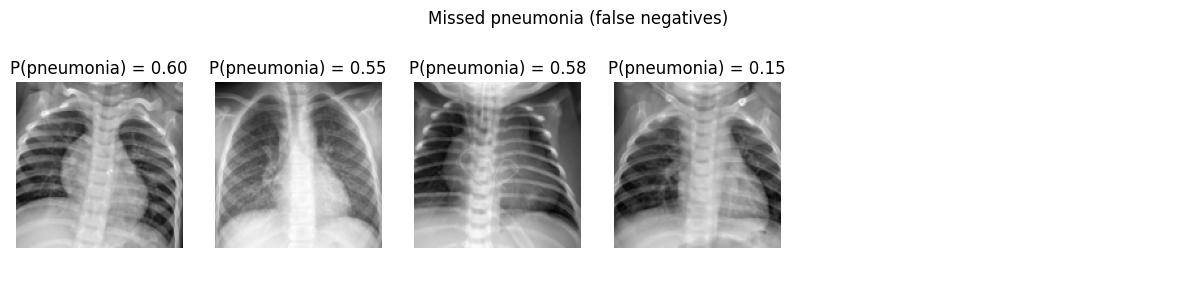

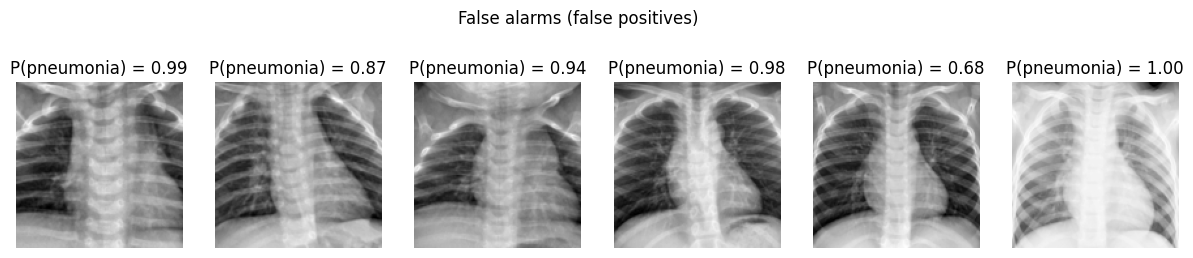

In [15]:
def plot_examples(mask: numpy.ndarray, title: str) -> None:
  indexes = numpy.flatnonzero(mask)[:6]
  if len(indexes) == 0:
    print(f"{title}: none")
    return
  _, axes = plt.subplots(1, 6, figsize=(15, 3.2))
  for ax in axes:
    ax.axis("off")
  for ax, index in zip(axes, indexes):
    ax.imshow(test_images[index], cmap="gray")
    ax.set_title(f"P(pneumonia) = {test_probabilities[index]:.2f}")
  plt.suptitle(title)
  plt.show()


test_predictions = (test_probabilities >= chosen_threshold).astype(int)
plot_examples((test_labels == 1) & (test_predictions == 0),
              "Missed pneumonia (false negatives)")
plot_examples((test_labels == 0) & (test_predictions == 1),
              "False alarms (false positives)")

## What if the Disease Were Rare?

In this dataset, most X-rays show pneumonia. In real screening, the disease is much rarer. With the same model, at the same threshold, what would precision become if only 5% of patients were sick?

In [16]:
PATIENTS = 1000
PREVALENCE = 0.05  # 5% of patients sick

# Rates measured on the test set: share of sick patients detected (the recall)
# and share of healthy children wrongly flagged
recall = (test_predictions[test_labels == 1] == 1).mean()
false_alarm_rate = (test_predictions[test_labels == 0] == 1).mean()

sick = PATIENTS * PREVALENCE
detected = recall * sick
false_alarms = false_alarm_rate * (PATIENTS - sick)
print(f"Out of {PATIENTS} patients, {sick:.0f} of them sick:")
print(f"- {detected:.0f} sick patients detected and {false_alarms:.0f} false alarms")
print(f"- precision: {detected / (detected + false_alarms):.0%}")

Out of 1000 patients, 50 of them sick:
- 49 sick patients detected and 215 false alarms
- precision: 19%


In our run: out of 1,000 patients, 50 of them sick, 49 are detected, at the cost of about 200 false alarms. Only about one alert in five concerns a really sick patient (precision of about 20%), against almost 9 in 10 in this dataset. Recall doesn't depend on how common the disease is, precision does: a model is validated on data that resembles its real use.

## What This Model Is Not

- **Not a medical device.** Software that helps with diagnosis is a medical device (EU regulation 2017/745): CE marking, clinical evaluation, post-market surveillance. Under the AI Act, it is a high-risk AI system. This notebook is a demo.
- **Not a bias-free model.** The X-rays come from children aged 1 to 5, from a single hospital (Guangzhou, China). Nothing says the model works on adults, in another hospital, with another machine: that would have to be checked on their data.
- **Not a doctor.** It only sees an image shrunk to 128 × 128 pixels, without the patient's symptoms or history, and doesn't tell bacterial from viral pneumonia. Its labels come from doctors, who can be wrong themselves.
- **Not proof of usefulness.** A good score on a public test set doesn't say patients will be better treated: that is measured by a clinical study, under real conditions of use.

## Takeaways

- With imbalanced classes, accuracy alone is misleading: always answering "pneumonia" already gets 62.5% on the test set. Always compare a model with a baseline that simple.
- The confusion matrix shows which errors the model makes. Recall counts the sick patients found, precision says whether an alert can be trusted.
- The decision threshold is a business (here, medical) choice: it is set on the validation set, from a goal, never by looking at the test set.
- A network pretrained on photos adapts to X-rays in a few minutes: transfer learning makes deep learning possible with a few thousand images.
- The validation score was optimistic, and precision depends on how common the disease is: only data from real use tells what a model is worth.
- A good score makes neither a medical device nor a bias-free model.